# Analyzing Virat Kohli’s Test Cricket Career

This project uses ball-by-ball Test cricket data to examine how Virat Kohli’s batting performance and dismissal patterns changed throughout his career.

In [38]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
data_dir = Path("player_data")
dataframes = []

In [40]:
for file in data_dir.glob("*.csv"):
    df = pd.read_csv(file)
    dataframes.append(df)

In [41]:
kohli_tests = pd.concat(dataframes, ignore_index=True)
kohli_tests = kohli_tests[kohli_tests["striker"] == "V Kohli"].sort_values("start_date")

Now that we have all the test matches he batted in and the matches sorted from the earliest start date, we will analyze his batting average over the years.

In [42]:
years = []
avg = []
for i in range(2011, 2026):
    years.append(i)
    runs = kohli_tests[kohli_tests["start_date"].str[:4] == str(i)]["runs_off_bat"].sum()
    dismissals = kohli_tests[kohli_tests["start_date"].str[:4] == str(i)]["player_dismissed"].eq("V Kohli").sum()
    avg.append((runs / dismissals))

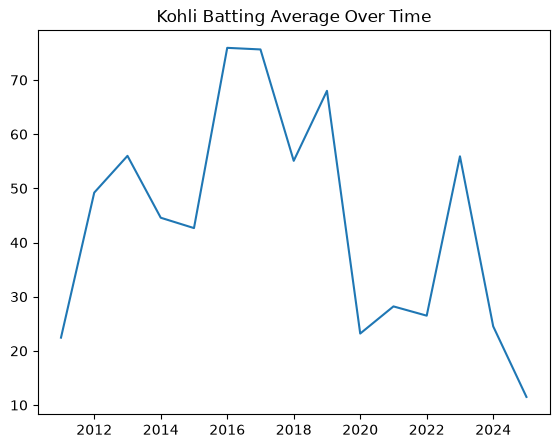

In [43]:
fig = plt.figure()
axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])
axes1.set_title("Kohli Batting Average Over Time")
axes1.plot(years, avg)
plt.show()

Kohli’s Test batting average followed a clear three-stage pattern across the period examined. He began his career with a solid but relatively modest average, then entered a prolonged period of exceptional form during the middle years. His average subsequently declined during the period following the COVID-19 pandemic. This suggests that his career was characterized by an initial development phase, a peak period of performance, and a later decline in batting average.

In [44]:
kohli_test_dismissals = kohli_tests[kohli_tests["player_dismissed"] == "V Kohli"].dropna(subset=["wicket_type"])

In [45]:
early_kohli_test_dismissals = kohli_test_dismissals[
    kohli_test_dismissals["start_date"].str[:4].astype(int).between(2011, 2015)
]

In [46]:
early_kohli_test_dismissals = early_kohli_test_dismissals.sort_values("start_date")

In [47]:
middle_kohli_test_dismissals = kohli_test_dismissals[
    kohli_test_dismissals["start_date"].str[:4].astype(int).between(2016, 2019)
]

In [48]:
middle_kohli_test_dismissals = middle_kohli_test_dismissals.sort_values("start_date")

In [49]:
late_kohli_test_dismissals = kohli_test_dismissals[
    kohli_test_dismissals["start_date"].str[:4].astype(int).between(2020, 2025)
]
late_kohli_test_dismissals = late_kohli_test_dismissals.sort_values("start_date")

In [50]:
dismissals = pd.DataFrame({
    "2011-2015": early_kohli_test_dismissals["wicket_type"].value_counts(),
    "2016-2019": middle_kohli_test_dismissals["wicket_type"].value_counts(),
    "2020-2025": late_kohli_test_dismissals["wicket_type"].value_counts()
}).fillna(0)

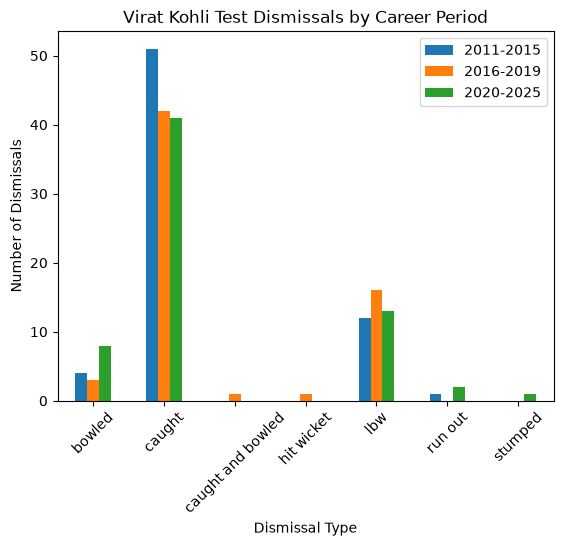

In [51]:
fig, ax = plt.subplots()

dismissals.plot(kind="bar", ax=ax)

ax.set_xlabel("Dismissal Type")
ax.set_ylabel("Number of Dismissals")
ax.set_title("Virat Kohli Test Dismissals by Career Period")
ax.tick_params(axis="x", rotation=45)

plt.show()

Caught dismissals were the most common dismissal type across the career periods examined. This suggests that catches were a major way Kohli lost his wicket, although the dataset does not establish which bowling locations or strategies caused those dismissals.